# **AI Bootcamp – Week 9 | Day 2 Lab**

# Image Generation Workflows

## Objectives

In this lab, you will explore advanced image generation workflows using Stable Diffusion. Unlike Day 1, where images were generated only from text prompts, today you will learn how to transform existing images, edit specific regions, guide image generation using structural information, and explore text-to-video generation.

By the end of this lab, you will be able to:

- Generate images using Image-to-Image (img2img)
- Understand how the Strength parameter affects generated images
- Edit images using Inpainting
- Guide image generation with ControlNet
- Explore text-to-video generation
- Improve prompts through systematic experimentation

# Step 1 – Enable GPU

Stable Diffusion models require GPU acceleration for efficient execution.

Before continuing:

1. Click **Runtime**
2. Select **Change runtime type**
3. Choose **T4 GPU**
4. Click **Save**

Run the following code to verify that your GPU is available.

In [1]:
import torch

if torch.cuda.is_available():
    print("GPU Available")
    print(torch.cuda.get_device_name(0))
else:
    print("GPU NOT Available")

GPU Available
Tesla T4


# Step 2 – Install Required Libraries

Today's lab requires several additional libraries.

Run the following cell.



In [2]:
!pip -q install diffusers transformers accelerate safetensors opencv-python-headless

# Step 3 – Import Libraries


Complete the missing imports below.

Hint:

You will need

- torch
- numpy
- PIL
- matplotlib
- load_image
- export_to_video

In [3]:
import torch
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt
from diffusers.utils import load_image, export_to_video

# Image-to-Image (img2img)

Unlike Day 1, today's generation starts with an existing image.

Instead of creating a completely new image, Stable Diffusion modifies the original while preserving some of its structure.

The amount of change is controlled by the **Strength** parameter.
# Load the Image-to-Image Pipeline


Complete the missing code.

Model name:

runwayml/stable-diffusion-v1-5

In [4]:
import torch
from diffusers import StableDiffusionImg2ImgPipeline

model_name = "runwayml/stable-diffusion-v1-5"

img2img_pipe = StableDiffusionImg2ImgPipeline.from_pretrained(
    model_name,
    torch_dtype=torch.float16
)

# Move pipeline to GPU
img2img_pipe = img2img_pipe.to("cuda")

print("Image-to-Image pipeline loaded successfully!")
print("Device:", img2img_pipe.device)

Flax classes are deprecated and will be removed in Diffusers v0.40.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.
Flax classes are deprecated and will be removed in Diffusers v0.40.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.


model_index.json:   0%|          | 0.00/541 [00:00<?, ?B/s]

Reconstructing (incomplete total...): |          |  0.00B /  0.00B            

Fetching 15 files:   0%|          | 0/15 [00:00<?, ?it/s]

Loading pipeline components...:   0%|          | 0/7 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/396 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/196 [00:00<?, ?it/s]

Image-to-Image pipeline loaded successfully!
Device: cuda:0


# Load the Sample Image

Run the following cell to download the sample image.

Feel free to swap in your own by uploading it to Colab and loading it with Image.open().

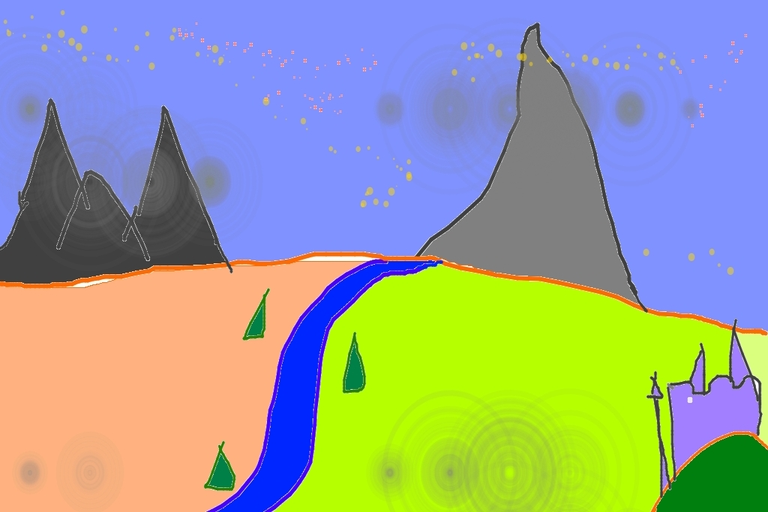

In [5]:
url = "https://raw.githubusercontent.com/CompVis/stable-diffusion/main/assets/stable-samples/img2img/sketch-mountains-input.jpg"
init_image = load_image(url).resize((768, 512))
init_image

 Experiment with the Strength Parameter

The **Strength** parameter determines how much the original image is modified.

Lower values preserve more of the original image.

Higher values generate a more dramatically changed image.


Generate the image using:

- Strength = 0.3
- Strength = 0.6
- Strength = 0.9

  0%|          | 0/9 [00:00<?, ?it/s]

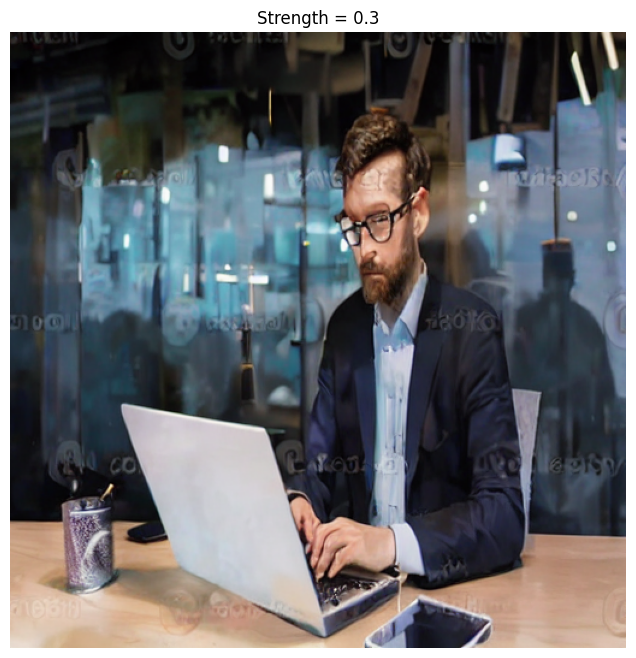

  0%|          | 0/18 [00:00<?, ?it/s]

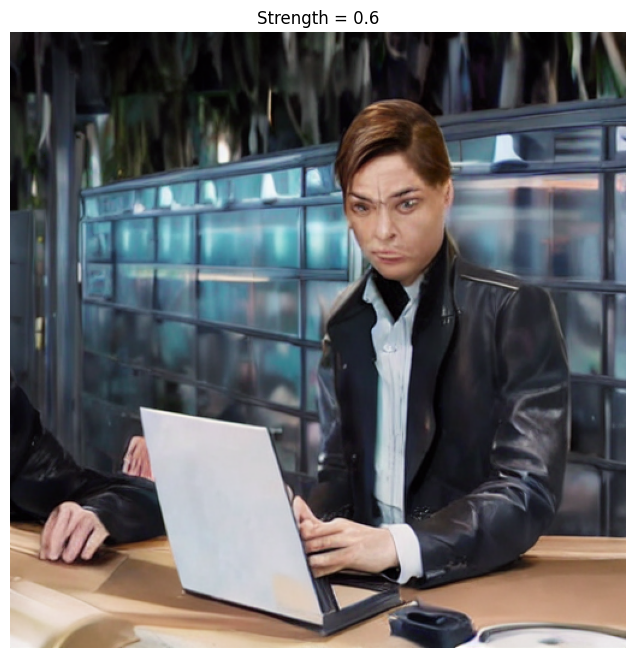

  0%|          | 0/27 [00:00<?, ?it/s]

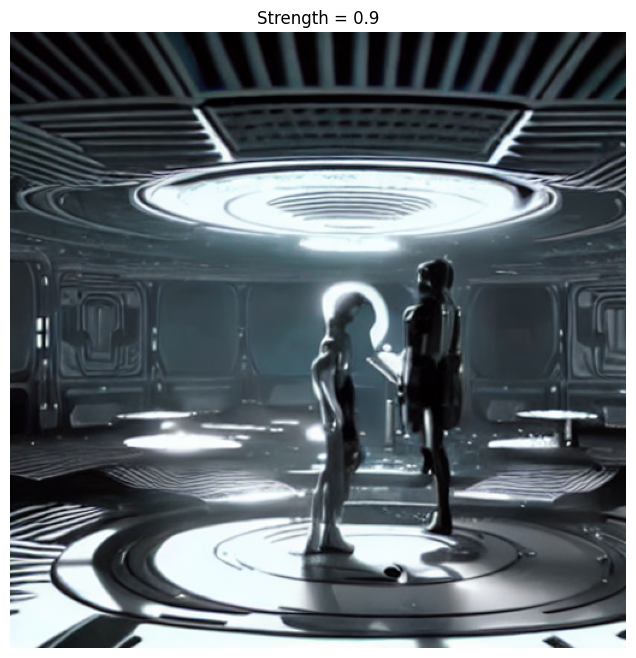

In [10]:
from PIL import Image
import matplotlib.pyplot as plt
import torch

# Load your original image
# Change the path if your image has a different name/location
init_image = Image.open("img.jpg").convert("RGB")

# Resize to a Stable Diffusion-friendly size
init_image = init_image.resize((512, 512))

prompt = "A futuristic cinematic version of this scene, highly detailed, realistic photography"

strength_values = [0.3, 0.6, 0.9]

# Use the same seed for a fair comparison
seed = 42

for strength in strength_values:

    generator = torch.Generator(device="cuda").manual_seed(seed)

    result = img2img_pipe(
        prompt=prompt,
        image=init_image,
        strength=strength,
        num_inference_steps=30,
        guidance_scale=8,
        generator=generator
    ).images[0]

    plt.figure(figsize=(8, 8))
    plt.imshow(result)
    plt.axis("off")
    plt.title(f"Strength = {strength}")
    plt.show()

## Reflection

1. Which strength preserved the original image best?

2. Which strength produced the largest transformation?

3. Which value would you choose if the client wanted only small edits?

# **Reflection**

**Which strength preserved the original image best?**

Strength = 0.3 preserved the original image best because the transformation was small.

**Which strength produced the largest transformation?**

Strength = 0.9 produced the largest transformation because the image was changed significantly.

**Which value would you choose if the client wanted only small edits?**

I would choose Strength = 0.3, because it keeps most of the original image while making only minor changes.

#  Inpainting

Instead of changing the whole image, Inpainting edits only the masked region.

The white region of the mask is regenerated.

The black region remains unchanged.

Load the Inpainting Pipeline


Complete the code below.

In [11]:
from diffusers import StableDiffusionInpaintPipeline
import torch

# Load the inpainting pipeline
pipe = StableDiffusionInpaintPipeline.from_pretrained(
    "runwayml/stable-diffusion-inpainting",
    torch_dtype=torch.float16
)

# Move the pipeline to GPU
pipe = pipe.to("cuda")

model_index.json:   0%|          | 0.00/548 [00:00<?, ?B/s]

Reconstructing (incomplete total...): |          |  0.00B /  0.00B            

Fetching 16 files:   0%|          | 0/16 [00:00<?, ?it/s]

Loading pipeline components...:   0%|          | 0/7 [00:00<?, ?it/s]

An error occurred while trying to fetch /root/.cache/huggingface/hub/models--runwayml--stable-diffusion-inpainting/snapshots/8a4288a76071f7280aedbdb3253bdb9e9d5d84bb/unet: Error no file named diffusion_pytorch_model.safetensors found in directory /root/.cache/huggingface/hub/models--runwayml--stable-diffusion-inpainting/snapshots/8a4288a76071f7280aedbdb3253bdb9e9d5d84bb/unet.
Defaulting to unsafe serialization. Pass `allow_pickle=False` to raise an error instead.
An error occurred while trying to fetch /root/.cache/huggingface/hub/models--runwayml--stable-diffusion-inpainting/snapshots/8a4288a76071f7280aedbdb3253bdb9e9d5d84bb/vae: Error no file named diffusion_pytorch_model.safetensors found in directory /root/.cache/huggingface/hub/models--runwayml--stable-diffusion-inpainting/snapshots/8a4288a76071f7280aedbdb3253bdb9e9d5d84bb/vae.
Defaulting to unsafe serialization. Pass `allow_pickle=False` to raise an error instead.


Loading weights:   0%|          | 0/396 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/196 [00:00<?, ?it/s]

  0%|          | 0/50 [00:00<?, ?it/s]

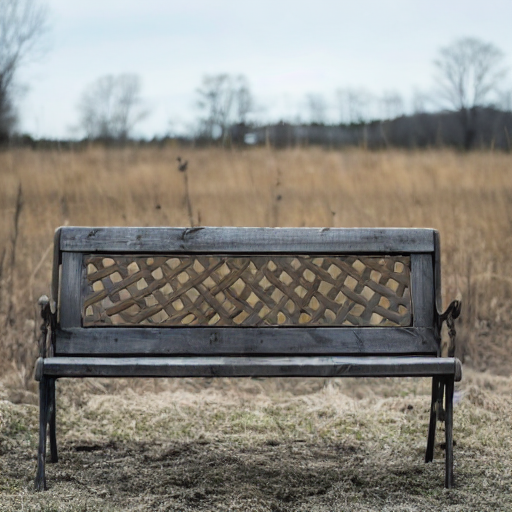

In [14]:
img_url = "https://raw.githubusercontent.com/CompVis/latent-diffusion/main/data/inpainting_examples/overture-creations-5sI6fQgYIuo.png"
mask_url = "https://raw.githubusercontent.com/CompVis/latent-diffusion/main/data/inpainting_examples/overture-creations-5sI6fQgYIuo_mask.png"

init_image = load_image(img_url).resize((512, 512))
mask_image = load_image(mask_url).resize((512, 512))

result = pipe(
    prompt="a beautiful green tree",
    image=init_image,
    mask_image=mask_image
).images[0]

display(result)

Load an image and its mask.

The mask is white where you want new content generated, and black where the original should stay untouched.

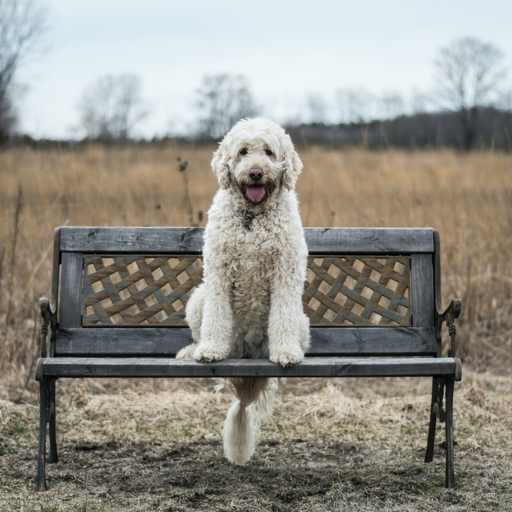

In [15]:
img_url = "https://raw.githubusercontent.com/CompVis/latent-diffusion/main/data/inpainting_examples/overture-creations-5sI6fQgYIuo.png"
mask_url = "https://raw.githubusercontent.com/CompVis/latent-diffusion/main/data/inpainting_examples/overture-creations-5sI6fQgYIuo_mask.png"

init_image = load_image(img_url).resize((512, 512))
mask_image = load_image(mask_url).resize((512, 512))

init_image

 Regenerate the masked region.

 **prompt =** "a majestic tiger sitting on a bench"

  0%|          | 0/50 [00:00<?, ?it/s]

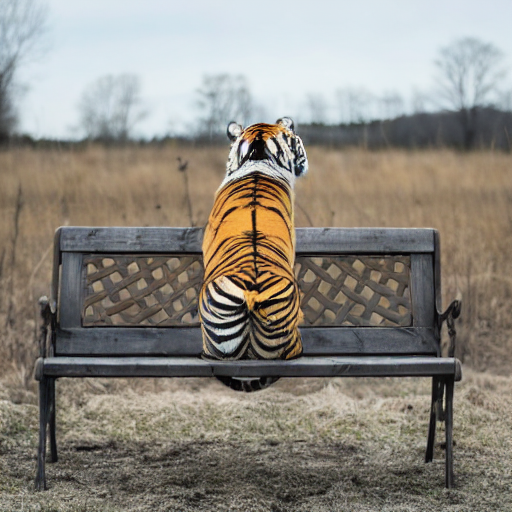

In [17]:
# Regenerate the masked region
prompt = "a majestic tiger sitting on a bench"

result = pipe(
    prompt=prompt,
    image=init_image,
    mask_image=mask_image
).images[0]

# Display the result
display(result)

##**Discussion**
    • Does the edited region blend naturally with the rest of the image?
    • What happens if you make the prompt vague vs. very specific?

# **Reflection**
**Does the edited region blend naturally with the rest of the image?**

Yes, if the mask is properly aligned and the prompt matches the original image's lighting, style, and surroundings. A poorly defined mask can make the edited area look unnatural.

**What happens if you make the prompt vague vs. very specific?**

A vague prompt gives the AI more freedom, so the result can be unpredictable. A specific prompt provides more details and usually gives a more controlled and accurate result.

 # **ControlNet**

 Install and load ControlNet

In [18]:
from diffusers import StableDiffusionControlNetPipeline, ControlNetModel
import cv2

controlnet = ControlNetModel.from_pretrained(
    "lllyasviel/sd-controlnet-canny",
    torch_dtype=torch.float16
)

pipe_cn = StableDiffusionControlNetPipeline.from_pretrained(
    "runwayml/stable-diffusion-v1-5",
    controlnet=controlnet,
    torch_dtype=torch.float16
).to("cuda")

/usr/local/lib/python3.13/dist-packages/huggingface_hub/utils/_validators.py:205: UserWarning: The `local_dir_use_symlinks` argument is deprecated and ignored in `hf_hub_download`. Downloading to a local directory does not use symlinks anymore.
  warnings.warn(


config.json:   0%|          | 0.00/920 [00:00<?, ?B/s]

diffusion_pytorch_model.safetensors: reconstructing file:   0%|          |  0.00B / 1.45GB            

diffusion_pytorch_model.safetensors: downloading bytes:           |  0.00B            

Loading pipeline components...:   0%|          | 0/7 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/396 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/196 [00:00<?, ?it/s]

Create a Canny edge map from a reference image

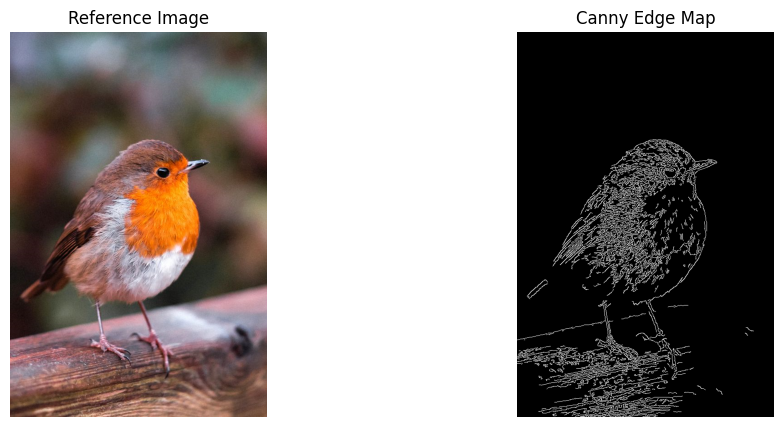

In [20]:
from diffusers.utils import load_image
from PIL import Image
import cv2
import numpy as np
import matplotlib.pyplot as plt

url = "https://huggingface.co/lllyasviel/sd-controlnet-canny/resolve/main/images/bird.png"
ref_image = load_image(url)

# Convert image to NumPy array
image = np.array(ref_image)

# Create Canny edge map
canny_image = cv2.Canny(image, 100, 200)

# Convert to 3-channel image
canny_image = canny_image[:, :, None]
canny_image = np.concatenate([canny_image] * 3, axis=2)

# Convert back to PIL Image
canny_image = Image.fromarray(canny_image)

# Display original and Canny edge map
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.imshow(ref_image)
plt.title("Reference Image")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(canny_image)
plt.title("Canny Edge Map")
plt.axis("off")

plt.show()

Generate guided by the edge map.

prompt = "a colorful parrot, highly detailed, studio lighting"

  0%|          | 0/50 [00:00<?, ?it/s]

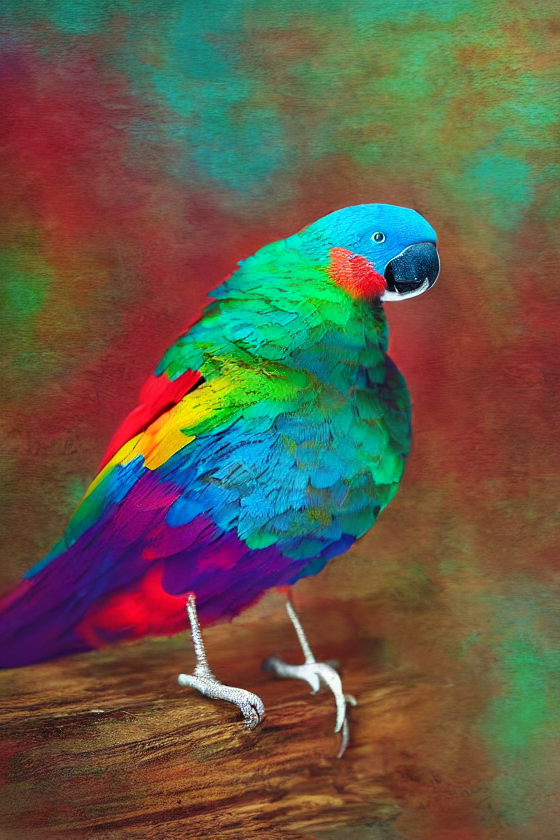

In [22]:
prompt = "a colorful parrot, highly detailed, studio lighting"

result = pipe_cn(
    prompt=prompt,
    image=canny_image
).images[0]

display(result)

# **Text-to-Video Exploration**

Load a lightweight text-to-video model

In [23]:
from diffusers import DiffusionPipeline, DPMSolverMultistepScheduler

pipe_video = DiffusionPipeline.from_pretrained(
    "damo-vilab/text-to-video-ms-1.7b",
    torch_dtype=torch.float16,
    variant="fp16"
)
pipe_video.scheduler = DPMSolverMultistepScheduler.from_config(pipe_video.scheduler.config)
pipe_video.enable_model_cpu_offload()

model_index.json:   0%|          | 0.00/384 [00:00<?, ?B/s]

Reconstructing (incomplete total...): |          |  0.00B /  0.00B            

Fetching 12 files:   0%|          | 0/12 [00:00<?, ?it/s]

Loading pipeline components...:   0%|          | 0/5 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/372 [00:00<?, ?it/s]

The TextToVideoSDPipeline has been deprecated and will not receive bug fixes or feature updates after Diffusers version 0.33.1. 


Generate a short clip

In [24]:
prompt = "a golden retriever running on a beach at sunset"

video_frames = pipe_video(prompt, num_inference_steps=25).frames[0]
video_path = export_to_video(video_frames)
video_path

  0%|          | 0/25 [00:00<?, ?it/s]

'/tmp/tmpa92fqak_.mp4'

Download the file from the Colab file browser (folder icon on the left) to watch it, or display it inline:

In [25]:
from IPython.display import Video
Video(video_path, embed=True)

Compare against a hosted demo.

Try the same prompt on one public text-to-video demo (e.g. a Hugging Face Space).

Note differences in quality, duration, and consistency.
# **Discussion**
    • How does video generation time compare to a single image?
    • What inconsistencies or artifacts do you notice across frames?

# **Reflection**
**How does video generation time compare to a single image?**

Video generation usually takes much longer than generating a single image because the model has to generate many frames while maintaining consistency between them.

**What inconsistencies or artifacts do you notice across frames?**

You may notice changes in the parrot's shape, feathers, colors, or position between frames. There can also be flickering, unnatural movements, distorted details, or background changes.